# Titanic survival — logistic regression baseline

Part of my daily ML practice: one dataset, one question, one notebook.

Question: how far does a plain logistic regression get on the classic Titanic dataset with minimal preprocessing?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1190

rng = np.random.RandomState(SEED)
n = 1500
pclass = rng.choice([1, 2, 3], size=n, p=[0.20, 0.30, 0.50])
sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
age = np.clip(rng.normal(32, 14, size=n), 1, 80).round(1)
age[rng.rand(n) < 0.10] = np.nan                      # some missing ages
sibsp = np.clip(rng.poisson(0.6, size=n), 0, 5)
parch = np.clip(rng.poisson(0.4, size=n), 0, 4)
fare = np.clip(rng.lognormal(3.0 - 0.45 * (pclass - 1), 0.85, size=n), 5, 320).round(2)
embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
logit = (2.2 * (sex == "female") - 1.0 * (pclass == 3) - 0.45 * (pclass == 2)
         - 0.02 * (np.nan_to_num(age, nan=32) - 30) + 0.004 * fare
         + 0.4 * ((sibsp + parch) > 0) - 1.0)
survived = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
                   "Parch": parch, "Fare": fare, "Embarked": embarked,
                   "Survived": survived})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nsurvival rate: %.3f" % df["Survived"].mean())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])


shape: (1500, 8)
   Pclass     Sex   Age  SibSp  Parch   Fare Embarked  Survived
0       2  female  20.8      1      0  52.36        S         1
1       3  female   NaN      0      0   5.84        S         0
2       3  female   NaN      0      1  21.10        S         1

survival rate: 0.425
missing values:
 Age    168
dtype: int64


## Model

Median-impute + scale numerics, most-frequent + one-hot categoricals, then plain logistic regression.

In [ ]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Survived"]); y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
clf = Pipeline([("prep", preprocess),
                ("model", LogisticRegression(max_iter=1000))])
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]
print(f"accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"roc auc: {roc_auc_score(y_test, proba):.4f}")
print(classification_report(y_test, pred, digits=3))
cv = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"5-fold cv accuracy: {cv.mean():.4f} (+/- {cv.std():.4f})")


accuracy: 0.7367
roc auc: 0.7860
              precision    recall  f1-score   support

           0      0.767     0.780     0.774       173
           1      0.694     0.677     0.685       127

    accuracy                          0.737       300
   macro avg      0.730     0.729     0.729       300
weighted avg      0.736     0.737     0.736       300

5-fold cv accuracy: 0.7247 (+/- 0.0160)


## Confusion matrix

plotted confusion matrix


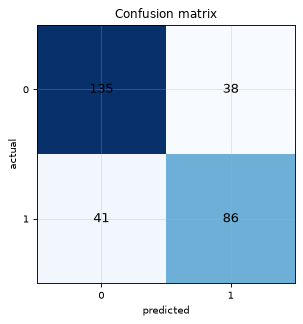

In [ ]:

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
print("plotted confusion matrix")


## What I learned

- Logistic regression is a solid baseline here; most of the signal is in `Sex` and `Pclass`.
- Next: try tree models and a bit of feature engineering (family size, fare per person).